In [ ]:
import torch
import torch.nn as nn
import math

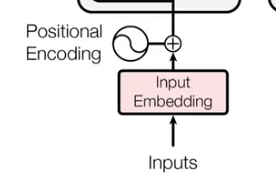
# Input Embedding

Maps the input to a high dimensional vector (provided by pytorch).
Embedding is a mapping between numbers and a vector, similar to a dictionary.

## Functions
### forward(self, x)
scales the input embedding by $$\frac{1}{\sqrt{d\_ model}}$$

**d_model** is the size of the embedding vector

In [26]:
class InputEmbeddings(nn.Module):
    def __init__(self, d_model: int, vocab_size: int):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, d_model)
        
    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

# Positional Encoding
Encode the input with data about the position of each word in a sentence.
You need to create a positional vector for each word in the sentence.
Positional encodings are only calculated once, they are saved and re used

$$positional encoding(2i)=\sin{\frac{pos}{10000^{\frac{2i}{d\_ model}}}}$$
$$positional encoding(2i + 1) = \cos{\frac{pos}{10000^ {\frac{2i}{d\_ model}}}}$$

## Functions

### forward(self, x)
add positional encoding to every word in sentence

---
## What is dropout
If a model relies too much on certain neurons, it can memorize the training data instead of learning general patterns.

This is called overfitting.

Overfitting means the model works well on training data but fails on new, unseen data.

Dropout helps because:

By randomly turning off neurons during training, the model has to spread the “work” across many neurons.

This makes it less likely to memorize specific details and better at generalizing to new data.

In [27]:
class Positional_Encoding(nn.Module):
    def __init__(self, d_model: int, seq_len: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout)
    
        # Create a matrix of shape (seq_len, d_model)
        positionalEncoding = torch.zeros(seq_len, d_model)
        
        # Create a vector of shape (seq_len)
        position = torch.arrange(0, seq_len, dtype=torch.float).unsqueeze(1) # pos in formula
        div_term = torch.exp(torch.arrange(0, d_model, 2).float() * (-math.log(10000.0)/d_model)) # denominator in formula
        
        # Apply sin to even positions
        positionalEncoding[:, 0::2] = torch.sin(position * div_term)
        positionalEncoding[:, 1::2] = torch.cos(position * div_term)
        
        # unsqueeze the positonalEncoding vector after batch processing (which is what you did above)
        positionalEncoding = position.unsqueeze(0) # shape 1, deq_len, d_model
        
        # Save the state of the model, the tensor is saved
        self.register_buffer('positionalEncoding', positionalEncoding)
    
    def forward(self, x):
        x = x + (self.positionalEncoding[:, :x.shape[1], :]).requires_grad_(False) # save the encoding
        return self.dropout(x)
    

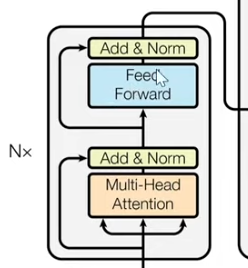
# Layer Normalization

If you have a batch of n items, you calculate the mean and varia

Think of layer normalization as a way to keep the values inside a neural network layer stable so training is easier. Here's a very simple breakdown:

A neural network layer has many numbers (activations) after applying weights.

Sometimes these numbers can be very big or very small, which makes training slow or unstable.

Layer normalization looks at all the numbers in that layer for one data point and:

Computes their average and spread (standard deviation).

Subtracts the average and divides by the spread → this makes the numbers have a mean of 0 and a standard deviation of 1.

Optionally, it can rescale and shift the numbers so the network can still learn the right values.

✅ Key point: Unlike batch normalization, layer normalization works on each example individually, not across a batch.

In short: layer normalization makes each layer’s outputs more “stable” so the network learns faster and better.

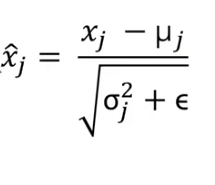

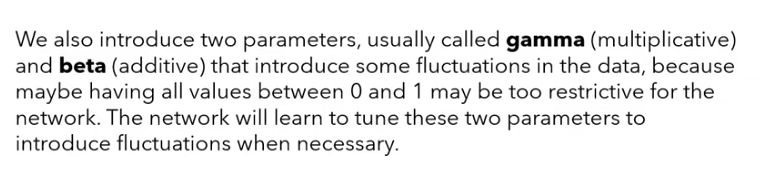

In [16]:
class LayerNormalization(nn.Module):
    def __init__(self, epsilon: float = 10**-6) -> None:
        super().__init__()
        self.epsilon = epsilon
        self.alpha = nn.Parameter(torch.ones(1)) # multiplied
        self.bias = nn.Parameter(torch.zeros(1)) # added
        
    def forward(self, x):
        mean = x.mean(dim = -1, keepdim = True)
        std = x.std(dim = -1, keepdim = True)
        
        return self.alpha * (x - mean) /  (std + self.eps) + self.bias
    

# Feed Forward Network (FFN)
The model uses this layer in both the encoder and the decoder.

In deep learning, a feedforward usually refers to a feedforward neural network or the feedforward part of a layer. Simply put:

Data flows forward only: Inputs go through the network without looping back (no cycles, unlike RNNs).

In [17]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.linear_1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear_2 = nn.Linear(d_ff, d_model)
        
    def forward(self, x):
        return self.linear_2(self.dropout(torch.relu(self.linear_1)))
        

# Multi-Head Attention

What this network does, is that it transforms the vector of a word given the context of the word in the sentence. The context is understood during the self-attention process.

For example, in the word "I took all my money out of the bank", once multi-headed attension discovers the context of bank and its connection with money, the FFN uses this context connection to transform the "bank" vector into a position that is closer to a money bank, and not a river bank.

In [18]:
class MultiHeadAttentionBlock(nn.Module):
    def __init__(self, d_model: int, h: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model
        self.h = h
        assert d_model % h == 0, "d_model is not divisible by h"
        
        self.d_k = d_model // h
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    
    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Dropout):
        d_k = query.shape[-1]
        
        attention_scores = (query @ key.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            attention_scores.masked_fill_(mask == 0, -1e9)        
        attention_scores = attention_scores.softmax(dim = -1)
        
        if dropout is not None:
            attention_scores = dropout(attention_scores)
        
        return (attention_scores @ value), attention_scores

    
    def forward(self, q, k, v, mask):
        query = self.w_q(q)
        key = self.w_k(k)
        value = self.w_v(v)
        
        query = query.view(query.shape[0], query.shape[1], self.h, self.d_k).transpose(1, 2)
        key = key.view(key.shape[0], key.shape[1], self.h, self.d_k).transpose(1, 2)
        value = value.view(key.shape[0], value.shape[1], self.h, self.d_k).transpose(1, 2)
        
        x, self.attention_scores = MultiHeadAttentionBlock.attention(query, key, value, mask, self.dropout)
        
        x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.h * self.d_k)
        
        return self.w_o(x)
    

# Finishing up the Encoder

In [19]:
class ResidualConnection(nn.Module):
    def __init__(self, dropout: float) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = LayerNormalization()
        
    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))

In [21]:
class EncoderBlock(nn.Module):
    def __init__(self, self_attention_block: MultiHeadAttentionBlock, 
                 feed_forward_block:FeedForwardBlock, 
                 dropout:float) -> None:
        
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connections = nn.ModuleList([ResidualConnection(dropout) for _ in range(2)])
        
    def forward(self, x, src_mask):
        x =  self.residual_connections[0](x, lambda x: self.self_attention_block(x, x, x, src_mask))
        x = self.residual_connections[1](x, self.feed_forward_block)
        
        return x

class Encoder(nn.Module):
    def __init__(self, layers:nn.ModuleList):
        self.layers = layers
        self.norm = LayerNormalization()
    
    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm

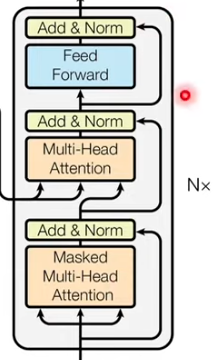

# Decoder block

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, self_attention_block: MultiHeadAttentionBlock, cross_attention_block: MultiHeadAttentionBlock, 
                 feed_forward_block: FeedForwardBlock, dropout: float) -> None:
        super().__init__()
        
        self.self_attention_block = self_attention_block
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        
        self.residual_connections = nn.ModuleList([ResidualConnection(dropout) for _ in range(3)])
        
    def forward(self, x, encoder_output, src_mask, tgt_mask):
        x = self.residual_connections[0](x, lambda x: self.self_attention_block(x, x, x, tgt_mask))
        x = self.residual_connections[1](x, lambda x: self.cross_attention_block(x, encoder_output, encoder_output, src_mask))
        x = self.residual_connections[2](x, self.feed_forward_block)
        
        return x


class Decoder(nn.Module):
    def __init__(self, layers: nn.ModuleList) -> None:
        super().__init__()
        
        self.layers = layers
        self.norm = LayerNormalization()
    
    def forward(self, x, encoder_output, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.norm(x)

        

# Linear Layer

Convert high dimensional space back into linear projection in the vocab

In [23]:
class ProjectionLayer(nn.Module):
    def __init(self, d_model: int, vocab_size: int) -> None:
        super().__init()
        self.proj = nn.Linear(d_model, vocab_size)
    
    def forward(self, x):
        return torch.log_softmax(self.proj(x), dim = -1)

# The Transformer

In [24]:
class Transformer(nn.Module):
    def __init__(self, 
                 encoder: Encoder, decoder: Decoder, 
                 src_embed: InputEmbeddings, tgt_embed: InputEmbeddings, 
                 src_pos: Positional_Encoding, tgt_pos: Positional_Encoding, 
                 projection_layer: ProjectionLayer) -> None:
    
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.src_pos = src_pos
        self.tgt_pos = tgt_pos
        self.projection_layer = projection_layer
        
    def encode(self, src, src_mask):
        src = self.src_embed(src)
        src = self.src_pos(src)
        return self.encoder(src, src_mask)
    
    def decode(self, encoder_output, src_mask, tgt, tgt_mask):
        tgt = self.tgt_embed(tgt)
        tgt = self.tgt_pos(tgt)
        return self.decoder(tgt, encoder_output, src_mask, tgt_mask)
    
    def project(self, x):
        return self.projection_layer(x)
    
        

In [ ]:
def build_transformer(src_vocab_size: int, tgt_vocab_size: int, 
                      src_seq_len: int, tgt_seq_len: int,
                      d_model: int = 512, 
                      N: int = 6, h: int = 8, dropout: float = 0.1, d_ff = 2048) -> Transformer:
    # Create embedding layers
    src_embed = InputEmbeddings(d_model, src_vocab_size)
    tgt_embed = InputEmbeddings(d_model, tgt_vocab_size)
    
    # Create the positional encoding layers
    src_pos =  Positional_Encoding(d_model, src_seq_len, dropout)
    tgt_pos = Positional_Encoding(d_model, tgt_seq_len, dropout)
    
    # Create the encoder blocks
    encoder_blocks = []
    for _ in range(N):
        encoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model, d_ff, dropout)
        encoder_block = FeedForwardBlock(d_model, d_ff, dropout)
        encoder_block = EncoderBlock(encoder_self_attention_block, feed_forward_block, dropout)
        
        encoder_blocks.append(encoder_block)

    # Create decoder blocks
    decoder_blocks = []
    for _ in range(N):
        decoder_self_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        decoder_cross_attention_block = MultiHeadAttentionBlock(d_model, h, dropout)
        feed_forward_block = FeedForwardBlock(d_model, d_ff, dropout)
        decoder_block = DecoderBlock(decoder_self_attention_block, decoder_cross_attention_block, feed_forward_block, dropout)
        decoder_blocks.append(decoder_block)
        
    # Create the encoder and the decoder
    encoder = Encoder(nn.ModuleList(encoder_blocks))
    decoder = Decoder(nn.ModuleList(decoder_blocks))
    
    # Create the projection layer
    projection_layer = ProjectionLayer(d_model, tgt_vocab_size)
    
    # Create the transformer
    transformer = Transformer(encoder, decoder, src_embed, tgt_embed, src_pos, tgt_pos, projection_layer)
    
    # Initialize the parameters to make learning faster
    for p in transformer.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform(p)
    
    return transformer
    
        